In [1]:
import os
import sys
sys.path.append("/home/amirabbas-kazeminia/Projects/DeepRT")

from Model.deeprt import DeepRT
model = DeepRT.load_from_checkpoint("/home/amirabbas-kazeminia/Projects/DeepRT/weights/1layers_2heads_24dim_10seed.ckpt")

In [2]:
import pandas as pd
monomers = pd.read_csv("/home/amirabbas-kazeminia/Projects/DeepRT/data/PEPLM_WORDS.csv")["words"].to_list()

In [3]:
import torch
embedding = torch.cat([model.sequence_embedding.weight[5:14,:],model.sequence_embedding.weight[15:20,:],model.sequence_embedding.weight[21:,:]], dim=0)

In [10]:
rep_2_smiles = {el['words']:el['smiles'] for el in pd.read_csv("/home/amirabbas-kazeminia/Projects/DeepRT/data/SMILES.csv").T.to_dict().values()}

In [25]:
from rdkit import Chem
from rdkit.Chem import Crippen, Descriptors

def compute_logp(smiles_list):
    results = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            logp = Crippen.MolLogP(mol)
            results.append(logp)
        else:
            results.append(None)  # Invalid SMILES
    return results

def compute_mass(smiles_list):
    results = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            mass = Descriptors.MolWt(mol)
            results.append(mass)
    return results

In [17]:
monomers_ = ['f',
 'A',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'L',
 'M',
 'N',
 'P',
 'Q',
 'S',
 'T',
 'V',
 'W',
 'Y']

In [26]:
smiles = [rep_2_smiles[monomer] for monomer in monomers_]
logP = compute_logp(smiles)
mw = compute_mass(smiles)

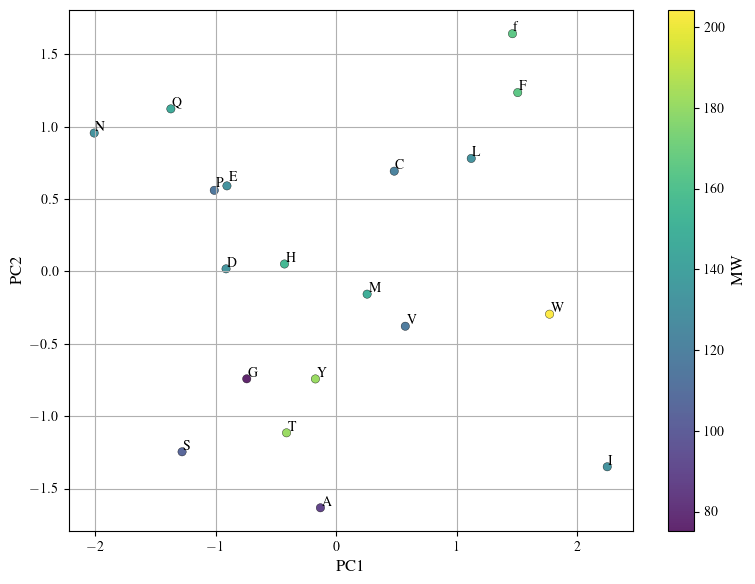

In [27]:
plot_pca(embedding, mw, 'MW', annotate_points=monomers_, save_path="/home/amirabbas-kazeminia/Projects/DeepRT/figures/monomer_embedding_w_MW.pdf")

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
%matplotlib inline
from adjustText import adjust_text

def plot_pca(
    tensor,
    values=None,
    value_name=None,
    title="PCA Projection",
    annotate_points=None,
    highlight_indices=None,
    cmap="viridis",
    figsize=(8, 6),
    use_latex=True,
    save_path=None,
):
    """
    Publication-quality PCA plot with optional value coloring and highlighting.

    Args:
        tensor (torch.Tensor or np.ndarray): Input features of shape (B, E)
        values (array-like or None): Optional 1D array of length B for coloring
        title (str): Title of the plot
        annotate_points (dict or None): Optional {index: label_text}
        highlight_indices (list or None): List of indices to highlight (e.g., red edges)
        cmap (str): Colormap
        figsize (tuple): Figure size
        use_latex (bool): Use LaTeX fonts
        save_path (str or None): Path to save the figure
    """
    if use_latex:
        import matplotlib as mpl
        mpl.rcParams.update({
            "text.usetex": True,
            "font.family": "serif",
            "font.serif": ["Times"],
            "axes.labelsize": 12,
            "font.size": 12,
            "legend.fontsize": 11,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
        })

    # Convert tensor to NumPy
    X = tensor.detach().cpu().numpy() if hasattr(tensor, 'detach') else np.asarray(tensor)

    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    fig, ax = plt.subplots(figsize=figsize)

    # Base scatter
    if values is not None:
        values = np.asarray(values)
        sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=values, cmap=cmap, alpha=0.85, edgecolor='k', linewidth=0.3)
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label(value_name)
    else:
        ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.85, edgecolor='k', linewidth=0.3)

    # Highlight specific indices
    if highlight_indices:
        highlight_indices = np.array(highlight_indices)
        ax.scatter(
            X_pca[highlight_indices, 0],
            X_pca[highlight_indices, 1],
            facecolors='none',
            edgecolors='red',
            linewidths=2,
            s=100,
            label="Highlighted"
        )
        ax.legend(loc="best")

    # Annotate points
    if annotate_points:
        texts = []
        for idx, text in enumerate(annotate_points):
            x, y = X_pca[idx]
            texts.append(ax.text(x, y, text, fontsize=10))
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))


    # Axis and title
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    # ax.set_title(title)
    ax.grid(True)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, format="pdf", bbox_inches="tight")
    plt.show()


In [3]:
import pandas as pd
data = pd.read_csv("../data/split/val_10.csv")
data_ = data.T.to_dict()
mapping = {datapoint["sequences"]:datapoint['B'] for datapoint in data_.values()}
sequences = data["sequences"].to_list()
B = data["B"].to_list()
Z = data["Z"].to_list()
M = data["M"].to_list()

In [4]:
AA_embed, post_trans, post_pool = model.get_embedding(sequences)

100%|██████████| 147/147 [00:00<00:00, 193.07it/s]


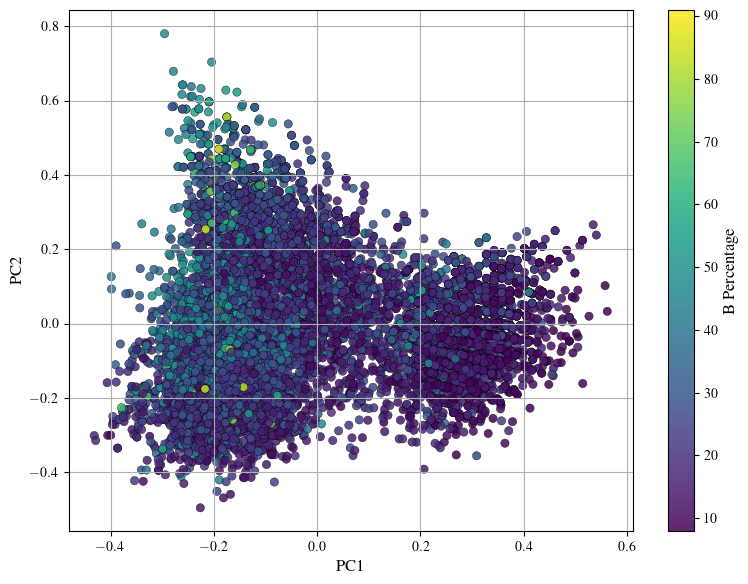

In [9]:
plot_pca(AA_embed, B, "B Percentage", save_path="/home/amirabbas-kazeminia/Projects/DeepRT/figures/pre_transformer_w_b.pdf")

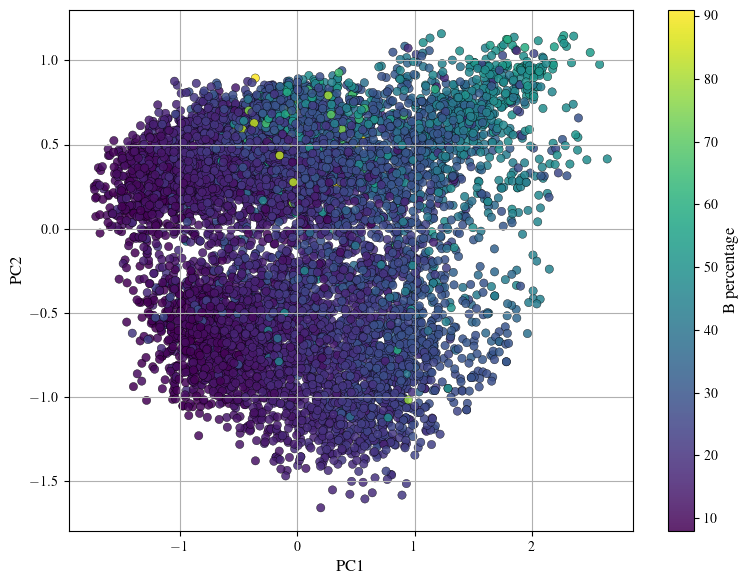

In [11]:
plot_pca(post_trans, B, "B percentage", save_path="/home/amirabbas-kazeminia/Projects/DeepRT/figures/post_transformer_w_B.pdf")

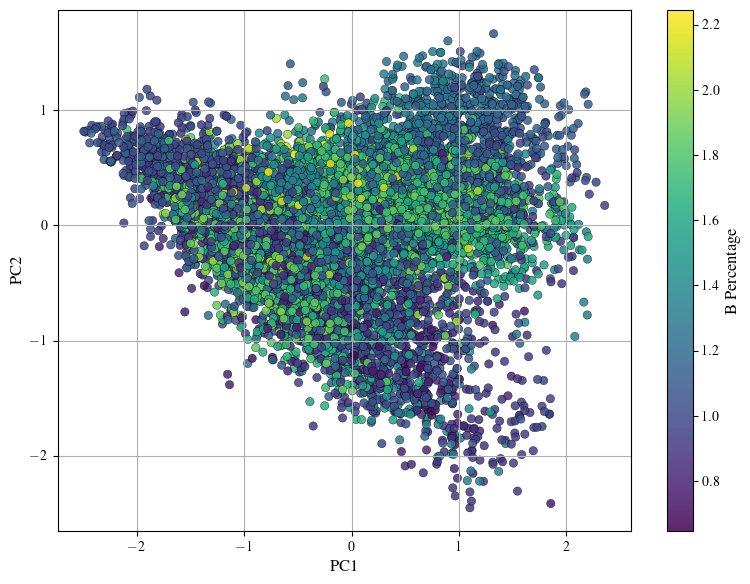

In [10]:
plot_pca(post_pool, M, "B Percentage")